In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf

In [2]:
def fetch_data(ticker, start_date = None, end_date = None, interval = "1d"):
    stock = yf.Ticker(ticker)
    ohlcv_df = stock.history(start = start_date, end = end_date, interval = interval)
    ohlcv_df_clean = ohlcv_df.dropna()
    return ohlcv_df_clean

In [3]:
data = fetch_data("KO", "2022-01-01", "2025-01-31")
data.reset_index(inplace = True)
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2022-01-03 00:00:00-05:00,53.741176,54.188868,53.339169,54.179729,20187300,0.0,0.0
1,2022-01-04 00:00:00-05:00,54.572603,55.312665,54.444692,55.084251,26141600,0.0,0.0
2,2022-01-05 00:00:00-05:00,54.901518,55.915675,54.864971,55.541077,22507300,0.0,0.0
3,2022-01-06 00:00:00-05:00,55.248707,55.842580,55.221295,55.248707,17902300,0.0,0.0
4,2022-01-07 00:00:00-05:00,55.075111,55.477121,54.874109,55.120796,12307900,0.0,0.0


### quater

Q1 (1st Quarter): January 1 to March 31

Q2 (2nd Quarter): April 1 to June 30

Q3 (3rd Quarter): July 1 to September 30

Q4 (4th Quarter): October 1 to December 31

### Useful Features
Moving Averages: Differences between short-term & long-term moving averages can help identify trends.

RSI (Relative Strength Index): Helps measure the speed & change of price movements. An RSI above 70 might indicate the stock is overbought, while below 30 could indicate oversold conditions.

MACD (Moving Average Convergence Divergence): Observing where the MACD line crosses the signal line can indicate bullish or bearish movement.

In [4]:
def RSI(data, window = 14):
    delta = data["Close"].diff()
    gain = delta.clip(lower = 0)
    loss = -delta.clip(upper = 0)
    avg_gain = gain.rolling(window = window).mean()
    avg_loss = loss.rolling(window = window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def MACD(data, span1 = 12, span2 = 26, signal = 9):
    exp1 = data["Close"].ewm(span = span1, adjust = False).mean()
    exp2 = data["Close"].ewm(span = span2, adjust = False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span = signal, adjust = False).mean()
    return macd, signal_line

data["RSI"] = RSI(data)
data["MACD"], data["Signal_Line"] = MACD(data)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month
data["Quarter"] = data["Date"].dt.quarter
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["Date"] = data["Date"].dt.date
data["Percent_Change"] = (data["Close"] - data["Open"]) / data["Open"] * 100
data["Increased(True/False)"] = np.where(data["Percent_Change"] > 0, True, False)
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,RSI,MACD,Signal_Line,Close_Open_Diff,Month,Quarter,Year,Day,Percent_Change,Increased(True/False)
0,2022-01-03,53.741176,54.188868,53.339169,54.179729,20187300,0.0,0.0,NaN,0.000000,0.000000,0.438554,1,1,2022,3,0.816048,True
1,2022-01-04,54.572603,55.312665,54.444692,55.084251,26141600,0.0,0.0,NaN,0.072156,0.014431,0.511648,1,1,2022,4,0.937555,True
2,2022-01-05,54.901518,55.915675,54.864971,55.541077,22507300,0.0,0.0,NaN,0.164307,0.044406,0.639559,1,1,2022,5,1.164921,True
3,2022-01-06,55.248707,55.842580,55.221295,55.248707,17902300,0.0,0.0,NaN,0.211311,0.077787,0.000000,1,1,2022,6,0.000000,False
4,2022-01-07,55.075111,55.477121,54.874109,55.120796,12307900,0.0,0.0,NaN,0.235525,0.109335,0.045686,1,1,2022,7,0.082951,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,2025-01-24,61.720001,62.009998,61.439999,61.919998,19244600,0.0,0.0,50.632896,-0.247193,-0.333948,0.199997,1,1,2025,24,0.324039,True
768,2025-01-27,62.869999,64.180000,62.470001,63.869999,20742900,0.0,0.0,62.958434,-0.074524,-0.282063,1.000000,1,1,2025,27,1.590584,True
769,2025-01-28,63.509998,64.040001,62.279999,62.360001,14956000,0.0,0.0,58.857142,-0.058848,-0.237420,-1.149998,1,1,2025,28,-1.810735,False
770,2025-01-29,62.560001,63.360001,62.549999,62.830002,11325600,0.0,0.0,60.826997,-0.008403,-0.191617,0.270000,1,1,2025,29,0.431586,True


In [5]:
column_order = ["Date", "Year", "Month", "Day", "Quarter", "Percent_Change", "Increased(True/False)", "Close_Open_Diff", "Open", "Close", "High", "Low", "Volume", "Dividends", "Stock Splits", "RSI", "MACD", "Signal_Line"]
data = data[column_order]
data.head(100)

,Date,Year,Month,Day,Quarter,Percent_Change,Increased(True/False),Close_Open_Diff,Open,Close,High,Low,Volume,Dividends,Stock Splits,RSI,MACD,Signal_Line
0,2022-01-03,2022,1,3,1,0.816048,True,0.438554,53.741176,54.179729,54.188868,53.339169,20187300,0.0,0.0,NaN,0.000000,0.000000
1,2022-01-04,2022,1,4,1,0.937555,True,0.511648,54.572603,55.084251,55.312665,54.444692,26141600,0.0,0.0,NaN,0.072156,0.014431
2,2022-01-05,2022,1,5,1,1.164921,True,0.639559,54.901518,55.541077,55.915675,54.864971,22507300,0.0,0.0,NaN,0.164307,0.044406
3,2022-01-06,2022,1,6,1,0.000000,False,0.000000,55.248707,55.248707,55.842580,55.221295,17902300,0.0,0.0,NaN,0.211311,0.077787
4,2022-01-07,2022,1,7,1,0.082951,True,0.045686,55.075111,55.120796,55.477121,54.874109,12307900,0.0,0.0,NaN,0.235525,0.109335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-05-19,2022,5,19,2,-1.574802,False,-0.883822,56.122744,55.238922,56.122744,54.925901,31493900,0.0,0.0,32.090101,-0.179572,0.289559
96,2022-05-20,2022,5,20,2,0.810048,True,0.451116,55.690036,56.141151,56.380522,54.925896,29133800,0.0,0.0,40.299633,-0.369746,0.157698
97,2022-05-23,2022,5,23,2,1.962691,True,1.113984,56.757991,57.871975,58.092929,56.702751,19406900,0.0,0.0,49.225341,-0.376458,0.050867
98,2022-05-24,2022,5,24,2,1.812970,True,1.049535,57.890387,58.939922,59.096438,57.770702,16154200,0.0,0.0,46.234128,-0.292234,-0.017754


In [6]:
data.dtypes

,0
Date,object
Year,int32
Month,int32
Day,int32
Quarter,int32
Percent_Change,float64
Increased(True/False),bool
Close_Open_Diff,float64
Open,float64
Close,float64


All variables are numerical.

In [7]:
data.isna().sum()

,0
Date,0
Year,0
Month,0
Day,0
Quarter,0
Percent_Change,0
Increased(True/False),0
Close_Open_Diff,0
Open,0
Close,0


No explicit outliers.

In [8]:
sns.pairplot(data)

Output hidden; open in https://colab.research.google.com to view.

In [9]:
data.Close_Open_Diff.max()

1.8689156640207187

In [10]:
data.Close_Open_Diff.min()

-3.8851348122278466

<Axes: ylabel='Close_Open_Diff'>

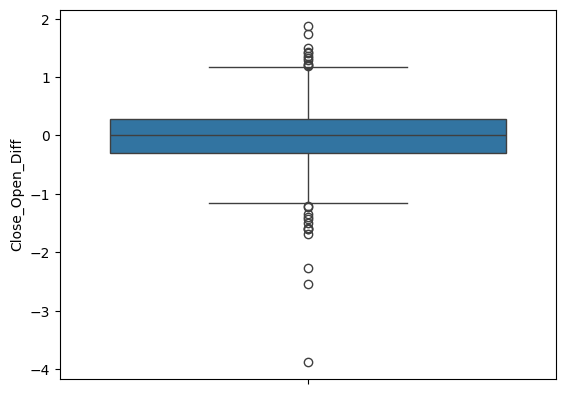

In [11]:
sns.boxplot(data.Close_Open_Diff)

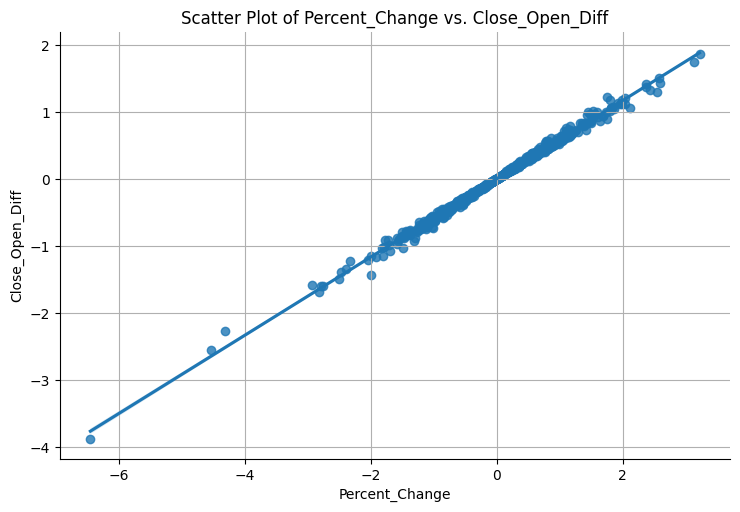

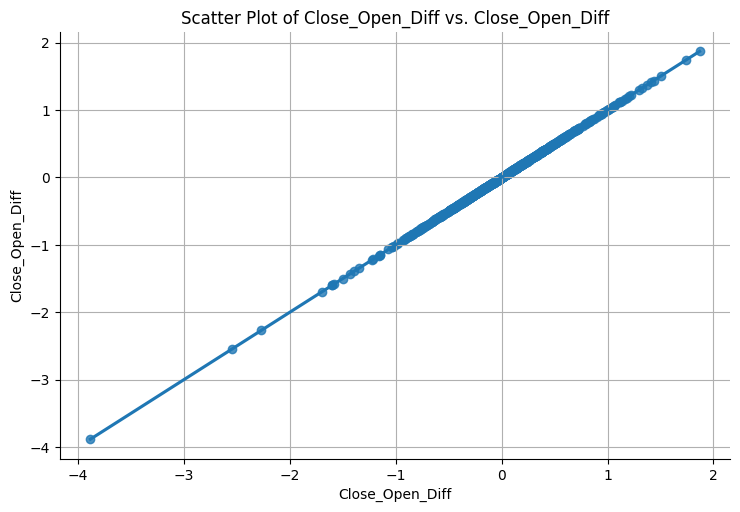

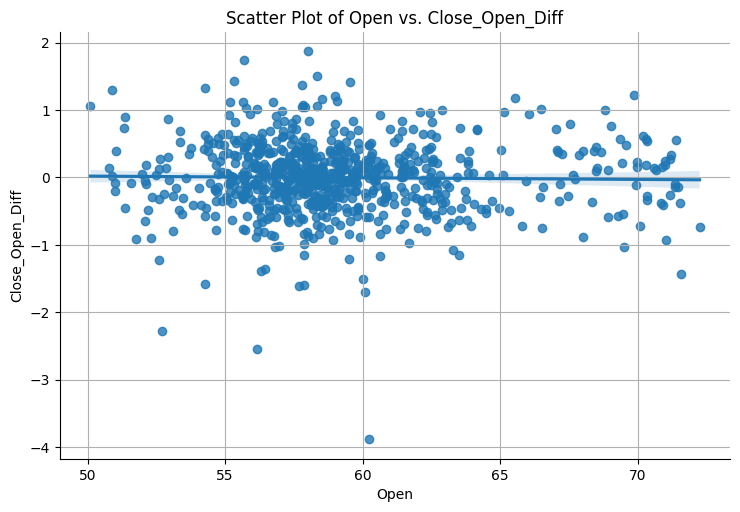

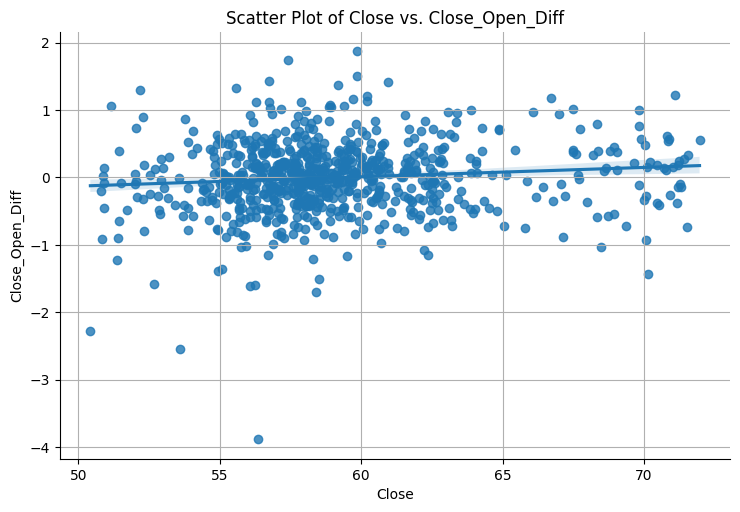

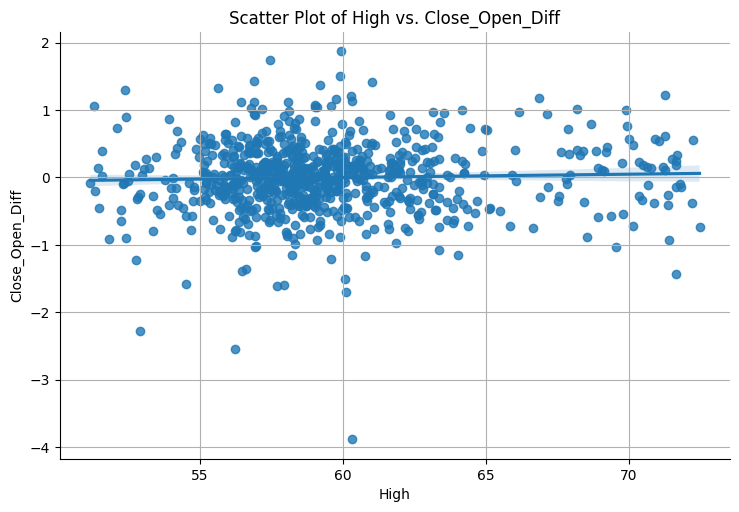

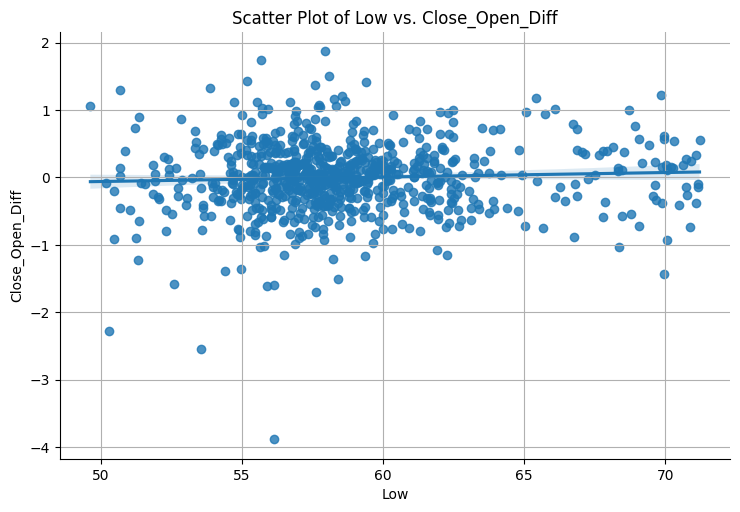

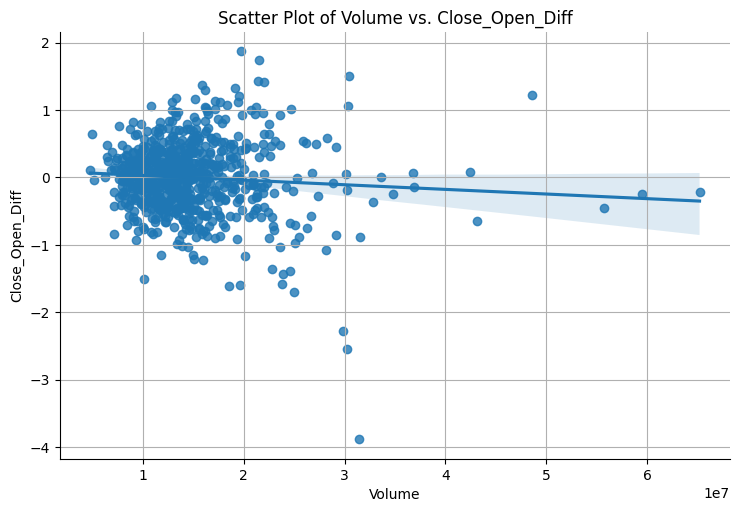

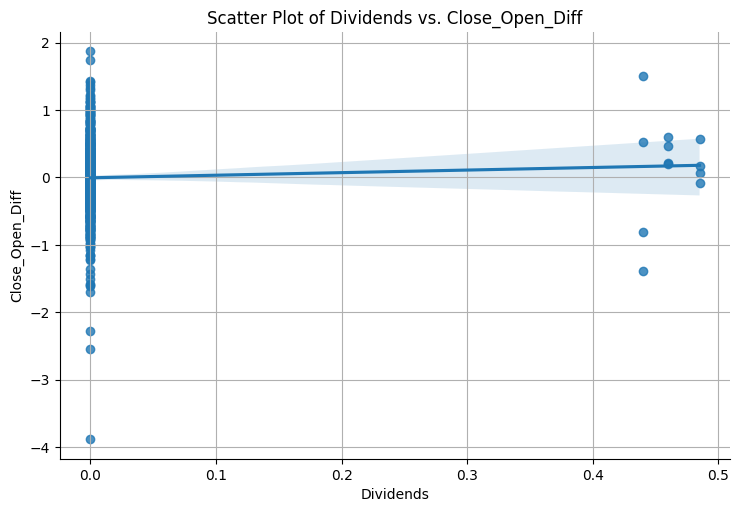

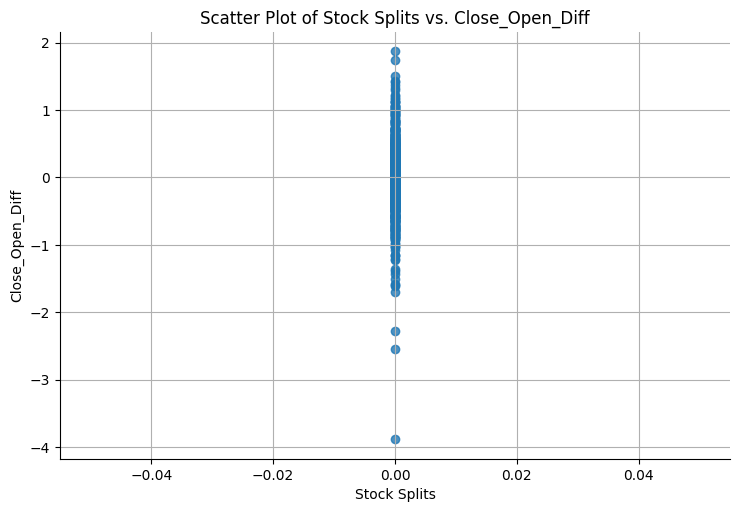

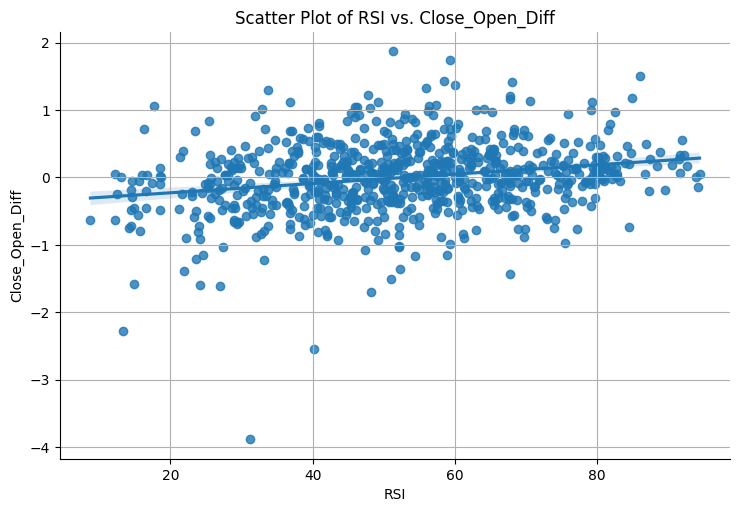

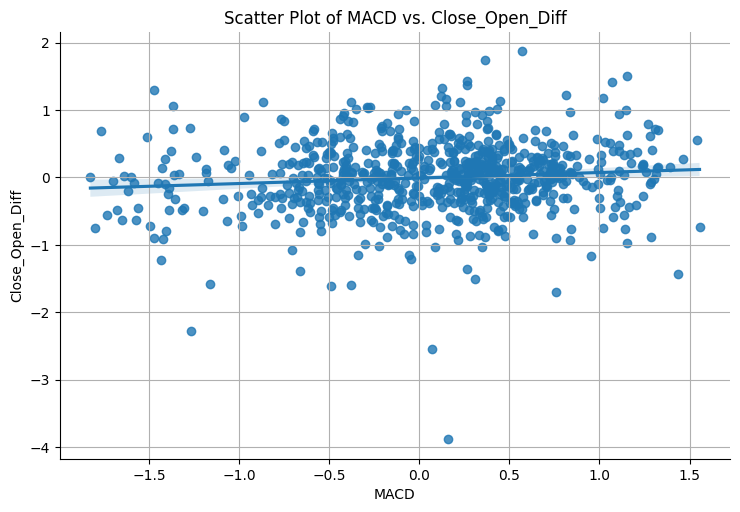

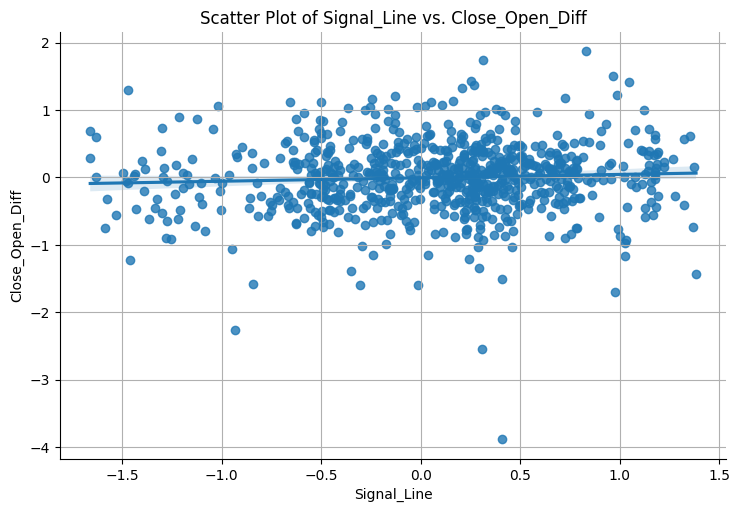

In [12]:
numerical_cols = data.select_dtypes(include = ["float64", "int64"]).columns
for col in numerical_cols:
    sns.lmplot(x = col, y = "Close_Open_Diff", data = data, aspect = 1.5, height = 5)
    plt.title(f"Scatter Plot of {col} vs. Close_Open_Diff")
    plt.xlabel(col)
    plt.ylabel("Close_Open_Diff")
    plt.grid(True)
    plt.show()

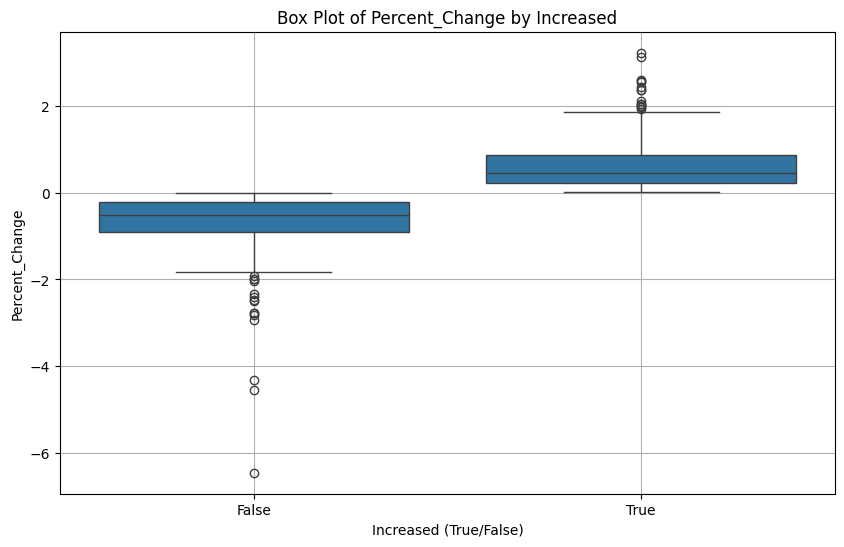

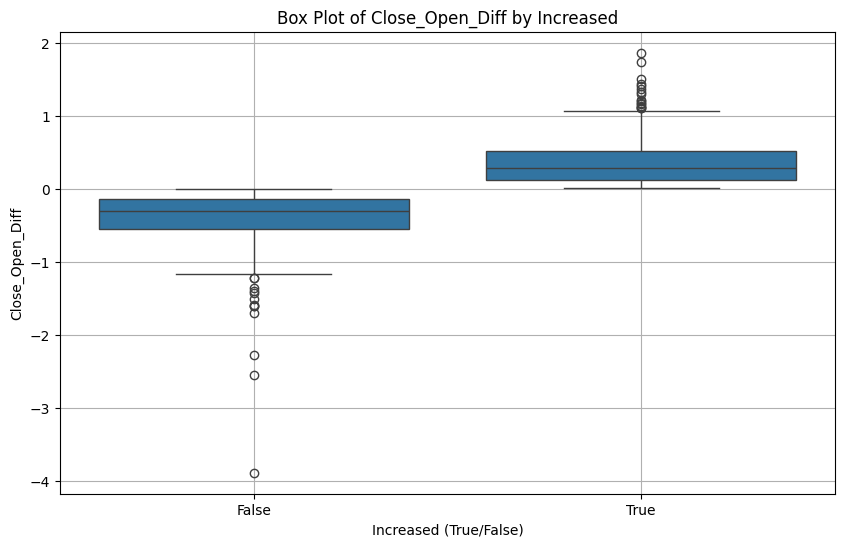

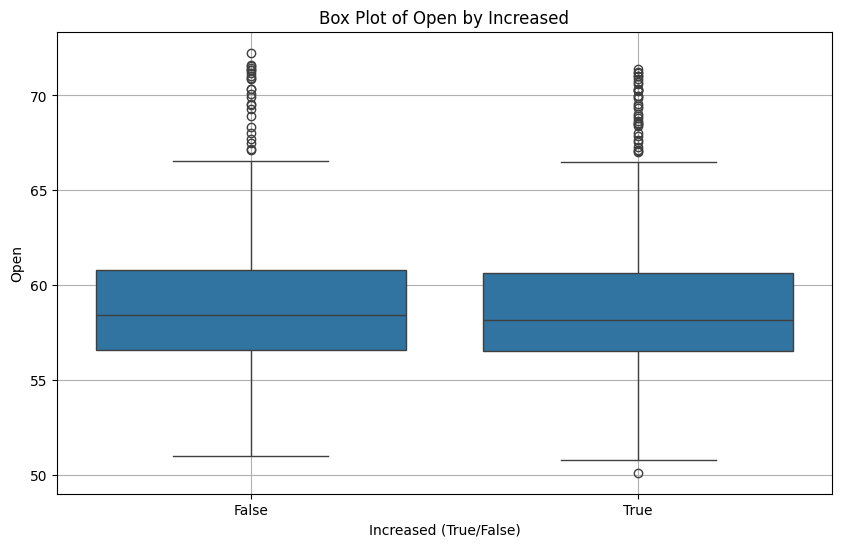

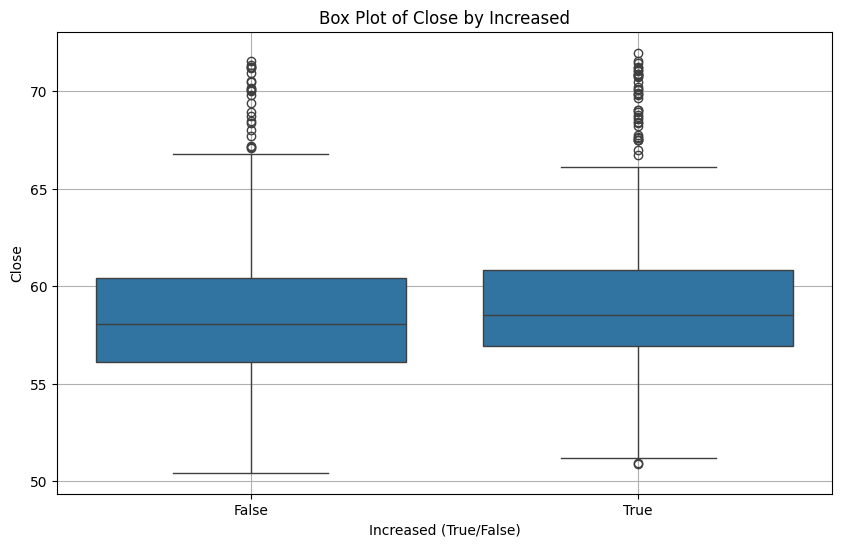

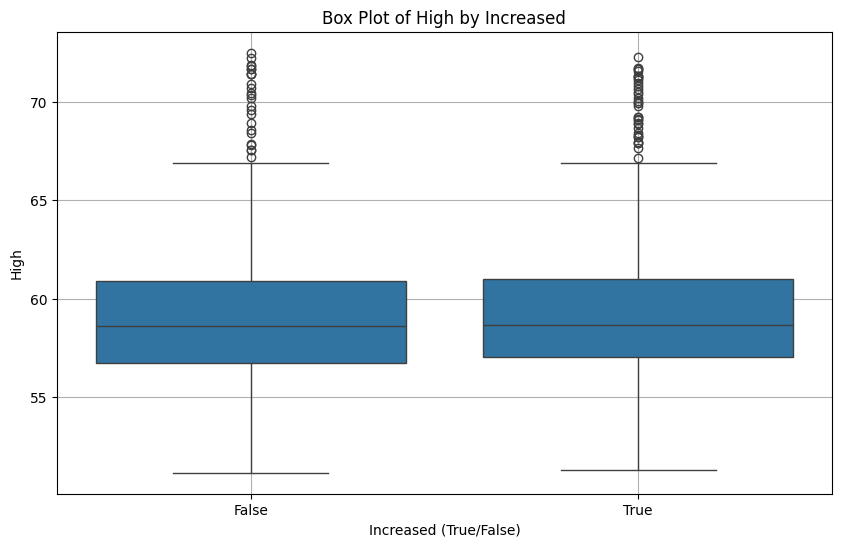

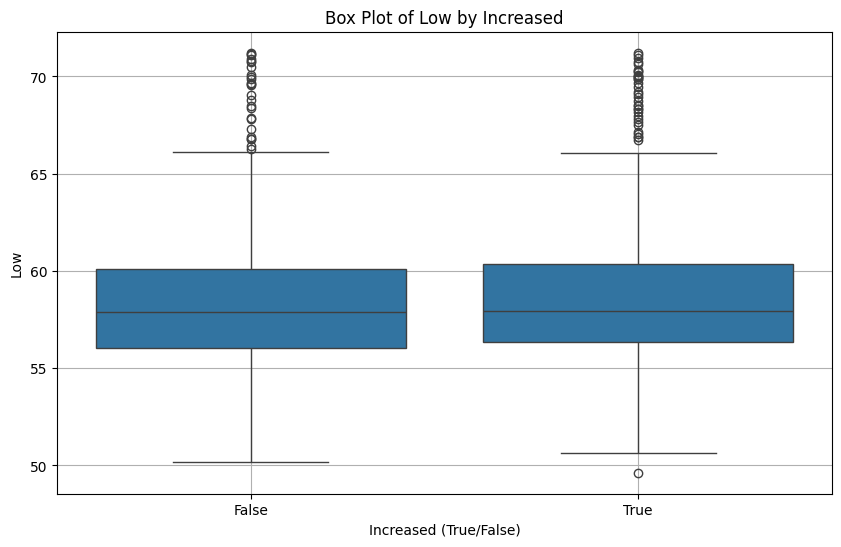

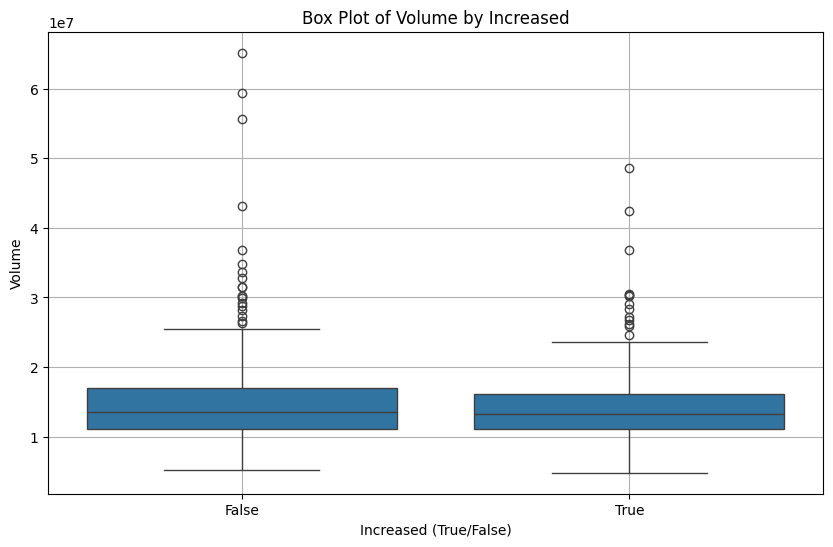

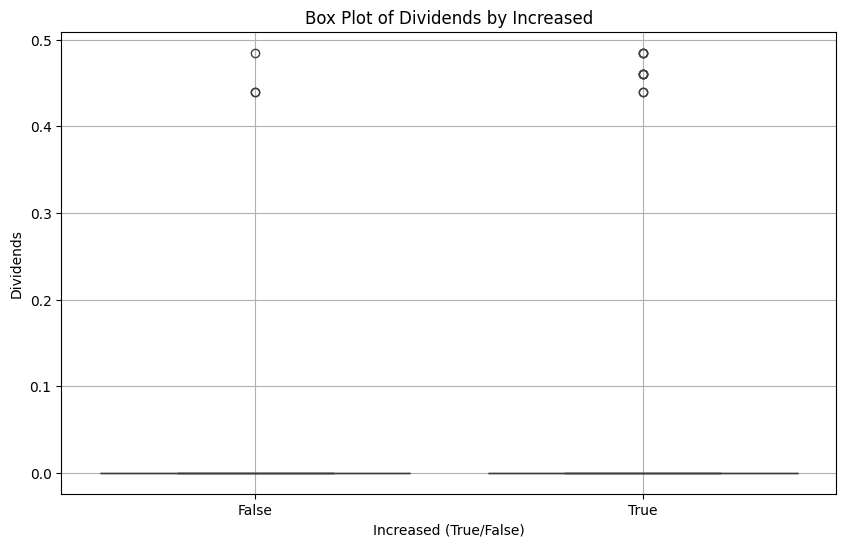

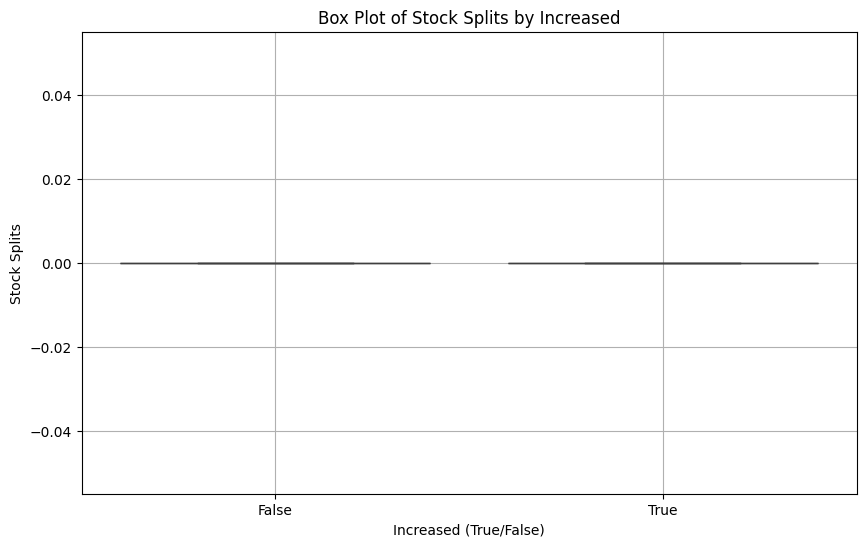

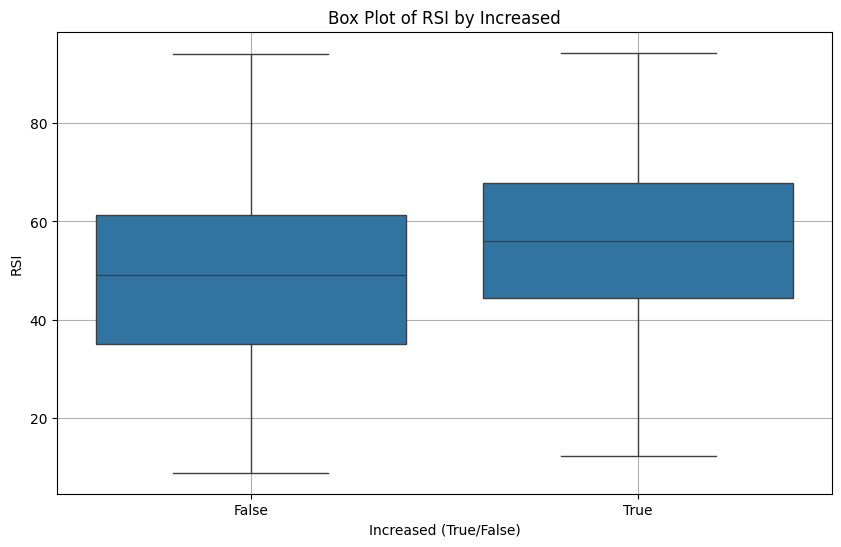

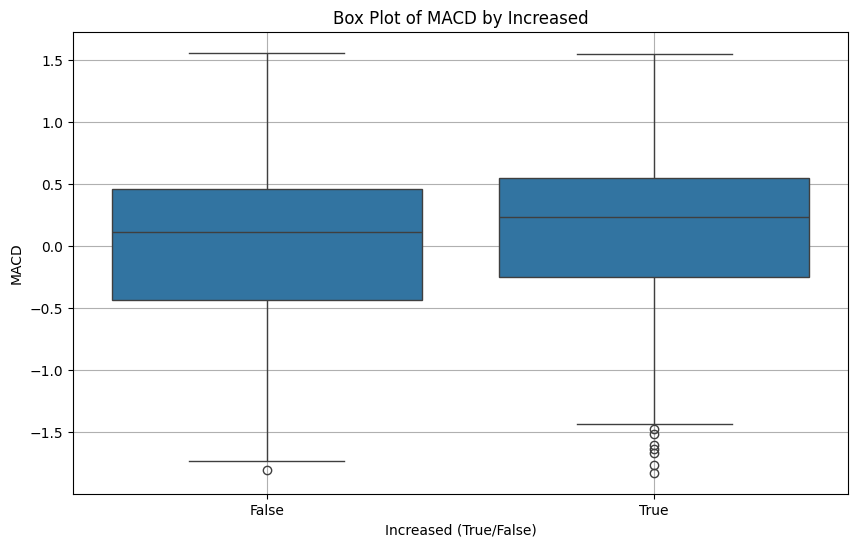

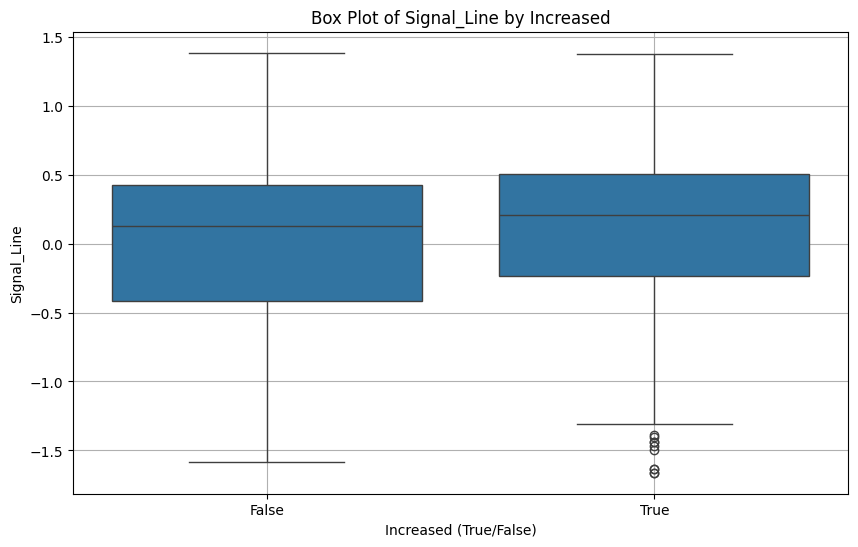

In [13]:
for col in numerical_cols:
    plt.figure(figsize = (10, 6))
    sns.boxplot(x = "Increased(True/False)", y = col, data = data)
    plt.title(f"Box Plot of {col} by Increased")
    plt.xlabel("Increased (True/False)")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

The close variable can be 1 of our response variable.

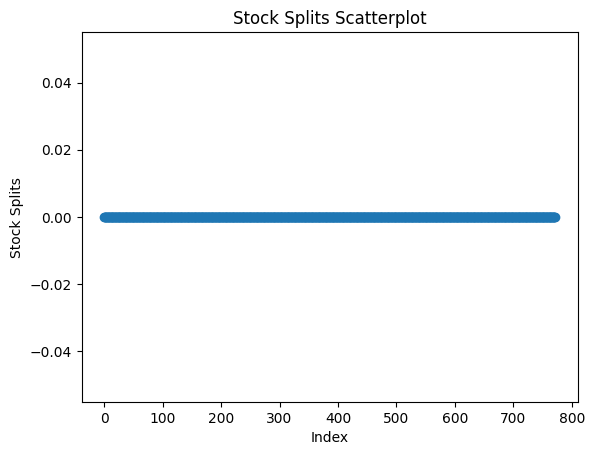

In [14]:
plt.scatter(data.index, data["Stock Splits"])
plt.xlabel("Index")
plt.ylabel("Stock Splits")
plt.title("Stock Splits Scatterplot")
plt.show()

In [15]:
data["Stock Splits"].value_counts()

,count
Stock Splits,
0.0,772


"Stock Splits" didn't happened or recored. The variable in this dataset is useless.

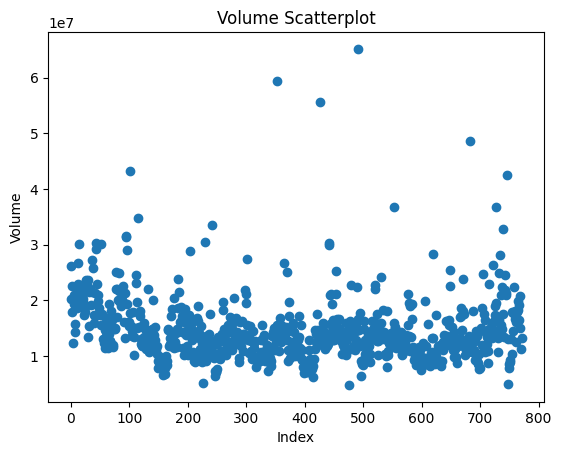

In [16]:
plt.scatter(data.index, data["Volume"])
plt.xlabel("Index")
plt.ylabel("Volume")
plt.title("Volume Scatterplot")
plt.show()

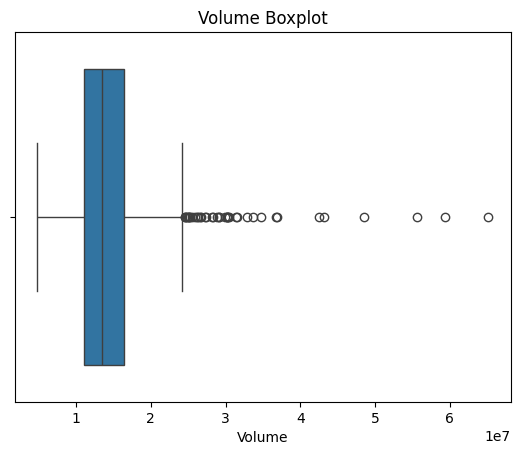

In [17]:
sns.boxplot(x = data["Volume"])
plt.title("Volume Boxplot")
plt.show()

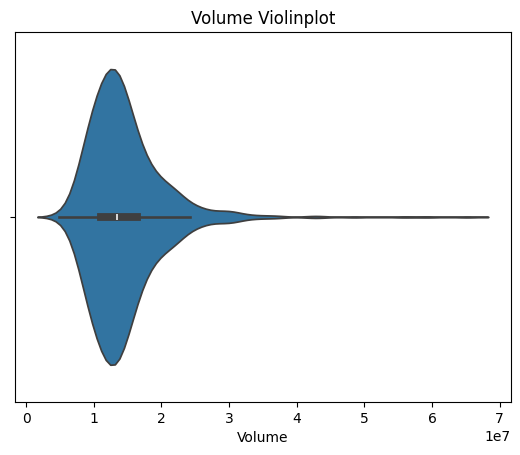

In [18]:
sns.violinplot(x = data["Volume"])
plt.title("Volume Violinplot")
plt.show()

In [19]:
Q1 = data["Volume"].quantile(0.25)
Q3 = data["Volume"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)
lower_outliers = data[data["Volume"] < lower_bound]
upper_outliers = data[data["Volume"] > upper_bound]
print("Lower outliers:")
print(lower_outliers)

3198225.0
24281025.0
Lower outliers:
Empty DataFrame
Columns: [Date, Year, Month, Day, Quarter, Percent_Change, Increased(True/False), Close_Open_Diff, Open, Close, High, Low, Volume, Dividends, Stock Splits, RSI, MACD, Signal_Line]
Index: []


In [20]:
print("Upper outliers:")
print(len(upper_outliers))
print(upper_outliers)

Upper outliers:
40
           Date  Year  Month  Day  Quarter  Percent_Change  \
1    2022-01-04  2022      1    4        1        0.937555   
13   2022-01-21  2022      1   21        1       -1.031436   
14   2022-01-24  2022      1   24        1        0.100163   
36   2022-02-24  2022      2   24        1        0.900445   
38   2022-02-28  2022      2   28        1        0.957016   
43   2022-03-07  2022      3    7        1       -1.499752   
44   2022-03-08  2022      3    8        1       -4.540278   
52   2022-03-18  2022      3   18        1       -0.331676   
77   2022-04-25  2022      4   25        2       -1.582086   
82   2022-05-02  2022      5    2        2       -2.818628   
94   2022-05-18  2022      5   18        2       -6.450623   
95   2022-05-19  2022      5   19        2       -1.574802   
96   2022-05-20  2022      5   20        2        0.810048   
102  2022-05-31  2022      5   31        2       -1.092386   
112  2022-06-14  2022      6   14        2       -2

We see there are 41 outliers of upper bound of volume meaning at these 41 days, the volume has increased drastically.

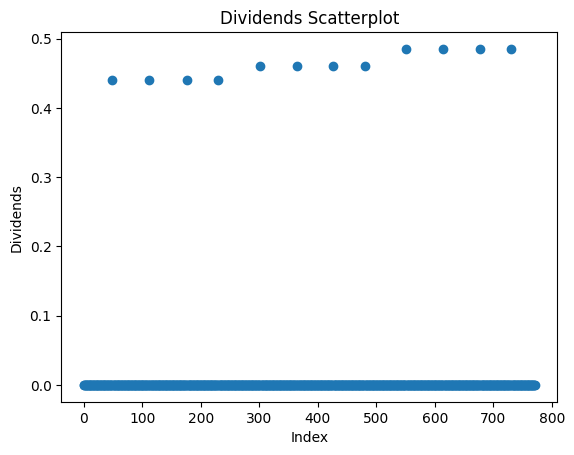

In [21]:
plt.scatter(data.index, data["Dividends"])
plt.xlabel("Index")
plt.ylabel("Dividends")
plt.title("Dividends Scatterplot")
plt.show()

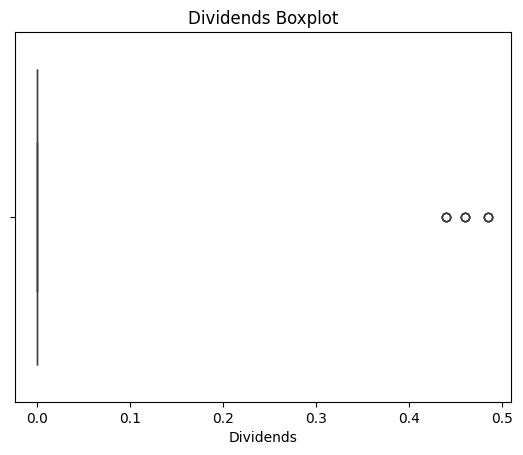

In [22]:
sns.boxplot(x = data["Dividends"])
plt.title("Dividends Boxplot")
plt.show()

In [23]:
data["Dividends"].value_counts()

,count
Dividends,
0.000,760
0.440,4
0.460,4
0.485,4


In [24]:
data[(data["Dividends"] == 0.44)]

,Date,Year,Month,Day,Quarter,Percent_Change,Increased(True/False),Close_Open_Diff,Open,Close,High,Low,Volume,Dividends,Stock Splits,RSI,MACD,Signal_Line
48,2022-03-14,2022,3,14,1,0.983267,True,0.524769,53.370006,53.894775,54.355100,53.370006,17799400,0.44,0.0,36.270228,-0.541532,-0.113893
112,2022-06-14,2022,6,14,2,-2.469949,False,-1.390950,56.314946,54.923996,56.463314,54.395435,24620000,0.44,0.0,21.901449,-0.661692,-0.349835
176,2022-09-15,2022,9,15,3,-1.440402,False,-0.812636,56.417288,55.604652,56.417288,55.445864,11451900,0.44,0.0,23.873016,-0.661539,-0.417260
229,2022-11-30,2022,11,30,4,2.580233,True,1.505099,58.331910,59.837009,59.902857,58.087334,30433900,0.44,0.0,86.086843,1.155684,0.964822


In [25]:
data[(data["Dividends"] == 0.46)]

,Date,Year,Month,Day,Quarter,Percent_Change,Increased(True/False),Close_Open_Diff,Open,Close,High,Low,Volume,Dividends,Stock Splits,RSI,MACD,Signal_Line
301,2023-03-16,2023,3,16,1,0.349474,True,0.199058,56.959377,57.158436,57.196353,56.589697,15658300,0.46,0.0,57.949385,-0.042919,-0.191647
364,2023-06-15,2023,6,15,2,1.022932,True,0.592174,57.889836,58.482010,58.548868,57.631953,15271400,0.46,0.0,62.401143,-0.439485,-0.587214
426,2023-09-14,2023,9,14,3,0.377743,True,0.211791,56.067533,56.279324,56.404475,56.019395,12311600,0.46,0.0,36.623384,-0.613872,-0.541748
480,2023-11-30,2023,11,30,4,0.828157,True,0.465774,56.242268,56.708042,56.727450,55.892937,22727500,0.46,0.0,84.171905,0.679703,0.576007


In [26]:
data[(data["Dividends"] == 0.485)]

,Date,Year,Month,Day,Quarter,Percent_Change,Increased(True/False),Close_Open_Diff,Open,Close,High,Low,Volume,Dividends,Stock Splits,RSI,MACD,Signal_Line
551,2024-03-14,2024,3,14,1,-0.132060,False,-0.078252,59.254823,59.176571,59.470008,59.078760,13996600,0.485,0.0,47.496823,0.167665,0.082935
615,2024-06-14,2024,6,14,2,0.272520,True,0.167570,61.488890,61.656460,61.794459,61.203032,8179200,0.485,0.0,62.280614,0.344054,0.428065
677,2024-09-13,2024,9,13,3,0.804641,True,0.565717,70.306743,70.872459,70.932005,69.949460,11073800,0.485,0.0,64.273908,0.983943,1.176991
731,2024-11-29,2024,11,29,4,0.093729,True,0.060005,64.019997,64.080002,64.250000,63.770000,10648400,0.485,0.0,56.157285,-0.774226,-1.196703


In [27]:
data.dtypes

,0
Date,object
Year,int32
Month,int32
Day,int32
Quarter,int32
Percent_Change,float64
Increased(True/False),bool
Close_Open_Diff,float64
Open,float64
Close,float64


In [28]:
Q1_dividends = data["Dividends"].quantile(0.25)
Q3_dividends = data["Dividends"].quantile(0.75)
IQR_dividends = Q3_dividends - Q1_dividends
lower_bound_dividends = Q1_dividends - 1.5 * IQR_dividends
upper_bound_dividends = Q3_dividends + 1.5 * IQR_dividends
lower_outliers_dividends = data[data["Dividends"] < lower_bound_dividends]
upper_outliers_dividends = data[data["Dividends"] > upper_bound_dividends]
print(lower_outliers_dividends)

Empty DataFrame
Columns: [Date, Year, Month, Day, Quarter, Percent_Change, Increased(True/False), Close_Open_Diff, Open, Close, High, Low, Volume, Dividends, Stock Splits, RSI, MACD, Signal_Line]
Index: []


In [29]:
print(Q1_dividends)

0.0


In [30]:
Q3_dividends

0.0

In [31]:
print(upper_outliers_dividends)

           Date  Year  Month  Day  Quarter  Percent_Change  \
48   2022-03-14  2022      3   14        1        0.983267   
112  2022-06-14  2022      6   14        2       -2.469949   
176  2022-09-15  2022      9   15        3       -1.440402   
229  2022-11-30  2022     11   30        4        2.580233   
301  2023-03-16  2023      3   16        1        0.349474   
364  2023-06-15  2023      6   15        2        1.022932   
426  2023-09-14  2023      9   14        3        0.377743   
480  2023-11-30  2023     11   30        4        0.828157   
551  2024-03-14  2024      3   14        1       -0.132060   
615  2024-06-14  2024      6   14        2        0.272520   
677  2024-09-13  2024      9   13        3        0.804641   
731  2024-11-29  2024     11   29        4        0.093729   

     Increased(True/False)  Close_Open_Diff       Open      Close       High  \
48                    True         0.524769  53.370006  53.894775  54.355100   
112                  False       

In [32]:
common_lower_outliers = lower_outliers.merge(lower_outliers_dividends, how = "inner", on = data.columns.tolist())
common_upper_outliers = upper_outliers.merge(upper_outliers_dividends, how = "inner", on = data.columns.tolist())
print("Common lower outliers between Volume & Dividends:")
print(common_lower_outliers)
print("Common upper outliers between Volume & Dividends:")
print(common_upper_outliers)

Common lower outliers between Volume & Dividends:
Empty DataFrame
Columns: [Date, Year, Month, Day, Quarter, Percent_Change, Increased(True/False), Close_Open_Diff, Open, Close, High, Low, Volume, Dividends, Stock Splits, RSI, MACD, Signal_Line]
Index: []
Common upper outliers between Volume & Dividends:
         Date  Year  Month  Day  Quarter  Percent_Change  \
0  2022-06-14  2022      6   14        2       -2.469949   
1  2022-11-30  2022     11   30        4        2.580233   

   Increased(True/False)  Close_Open_Diff       Open      Close       High  \
0                  False        -1.390950  56.314946  54.923996  56.463314   
1                   True         1.505099  58.331910  59.837009  59.902857   

         Low    Volume  Dividends  Stock Splits        RSI      MACD  \
0  54.395435  24620000       0.44           0.0  21.901449 -0.661692   
1  58.087334  30433900       0.44           0.0  86.086843  1.155684   

   Signal_Line  
0    -0.349835  
1     0.964822  


Relatinship between open & volume is no or weak linear relationship.
We should avoid using both open & close variables which will cause the m
multicollinearity.

<ipython-input-34-760ff2cefd8a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Volume_Change"] = data["Volume"].diff()


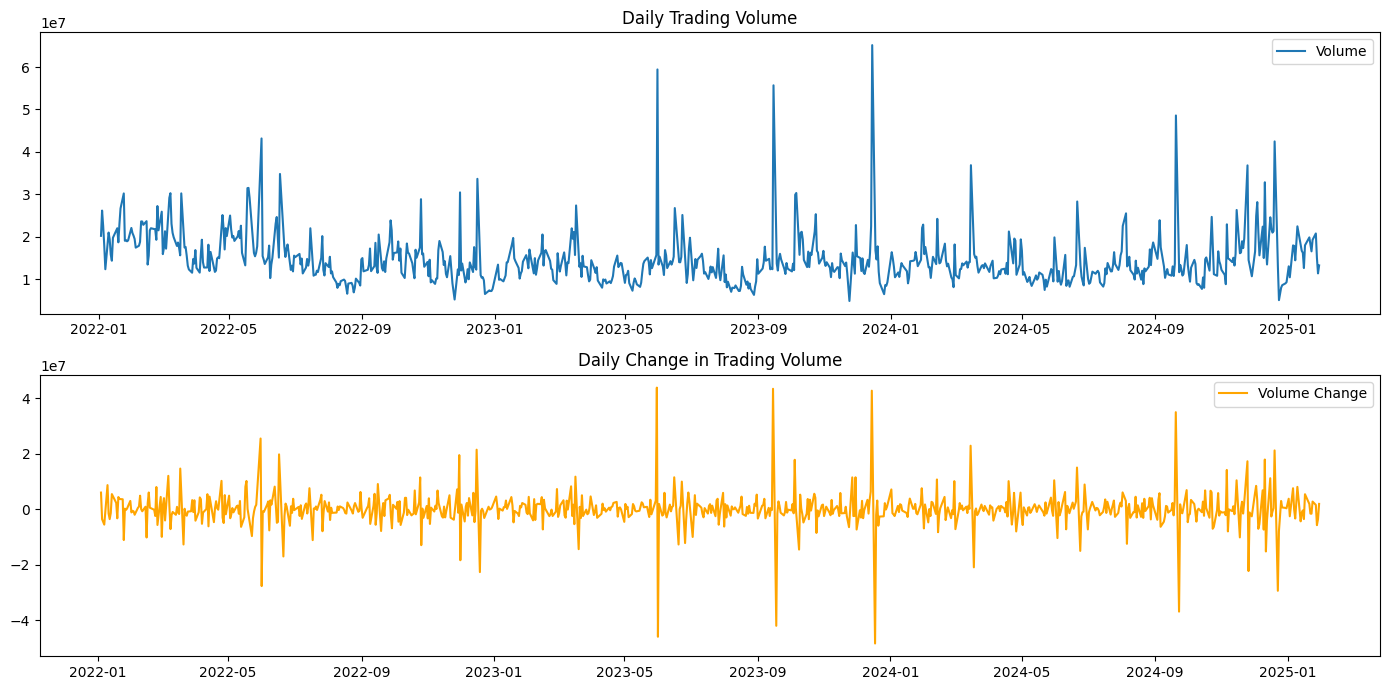

In [34]:
data["Volume_Change"] = data["Volume"].diff()
plt.figure(figsize = (14, 7))
plt.subplot(2, 1, 1)
plt.plot(data["Date"], data["Volume"], label = "Volume")
plt.title("Daily Trading Volume")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(data["Date"], data["Volume_Change"], label = "Volume Change", color = "orange")
plt.title("Daily Change in Trading Volume")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
def fetch_news_articles(ticker, from_date = None, to_date = None, language = "en", page_size = 100):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": ticker,
        "apiKey": "6920c0ee94ef49539a8c84af9ed1ea58",
        "language": language,
        "pageSize": page_size,
        "from": from_date,
        "to": to_date,
        "sortBy": "relevancy"
    }
    response = requests.get(url, params = params)
    data = response.json()
    if data.get("status") == "ok":
        articles = data.get("articles", [])
        news_df = pd.DataFrame(articles)[["publishedAt", "title", "description", "url", "content"]]
        news_df["publishedAt"] = pd.to_datetime(news_df["publishedAt"])
        return news_df
    else:
        raise Exception(f"Error fetching news: {data.get('message', 'Unknown error')}")


In [40]:
news_df = fetch_news_articles("GOOG", "2025-02-04", "2025-03-03")
news_df

,publishedAt,title,description,url,content
0,2025-02-05 22:35:00+00:00,"Big Tech's AI spending, Treasury yields plunge...","US stocks (^GSPC, ^IXIC, ^DJI) closed higher a...",https://finance.yahoo.com/video/big-techs-ai-s...,"US stocks (^GSPC, ^IXIC, ^DJI) closed higher a..."
1,2025-02-06 16:09:08+00:00,What's Happening With GOOG Stock?,Although Google continued to benefit from its ...,https://www.forbes.com/sites/greatspeculations...,"SUQIAN, CHINA - FEBRUARY 05: In this photo ill..."
2,2025-02-04 17:15:00+00:00,Now generally available: Easily migrate files ...,"What’s changing In October 2024, we expanded o...",http://workspaceupdates.googleblog.com/2025/02...,"What’s changingIn October 2024, we expanded ou..."
3,2025-02-12 11:19:42+00:00,"Leaking the email of any YouTube user for $10,000",What could've been the largest data breach in ...,https://brutecat.com/articles/leaking-youtube-...,"&lt; Back2025-02-12\r\nSome time ago, I was lo..."
4,2025-02-25 18:53:54+00:00,Why GOOG Stock Is Dropping Today,None,https://consent.yahoo.com/v2/collectConsent?se...,"If you click 'Accept all', we and our partners..."
...,...,...,...,...,...
95,2025-02-05 11:26:50+00:00,Concord Asset Management LLC VA Sells 285 Shar...,Concord Asset Management LLC VA decreased its ...,https://www.etfdailynews.com/2025/02/05/concor...,Concord Asset Management LLC VA decreased its ...
96,2025-02-07 09:14:48+00:00,Deepwater Asset Management LLC Trims Stock Hol...,Deepwater Asset Management LLC decreased its h...,https://www.etfdailynews.com/2025/02/07/deepwa...,Deepwater Asset Management LLC decreased its h...
97,2025-02-07 09:49:22+00:00,Lazari Capital Management Inc. Purchases 166 S...,Lazari Capital Management Inc. grew its positi...,https://www.etfdailynews.com/2025/02/07/lazari...,Lazari Capital Management Inc. grew its positi...
98,2025-02-19 11:04:56+00:00,Scarborough Advisors LLC Buys 527 Shares of Al...,Scarborough Advisors LLC boosted its stake in ...,https://www.etfdailynews.com/2025/02/19/scarbo...,Scarborough Advisors LLC boosted its stake in ...
